In [1]:
import pandas as pd
import numpy as np

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    RocCurveDisplay
)

In [37]:
# Load data
data = pd.read_csv(r'D:\Rejo\Course\Data_Analyst\Class\Project\Telco_Cusomer_Churn.csv')
print("Shape:", data.shape)

Shape: (7043, 21)


In [38]:
print(data.head())

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [40]:
data.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [64]:
# Data Understanding & Cleaning

print("\nInfo:")
print(data.info())


Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   o

In [6]:
print("\nMissing values before cleaning:")
print(data.isnull().sum())


Missing values before cleaning:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [7]:
numerical_features_list = ["tenure", "MonthlyCharges", "TotalCharges"]
for col in data.columns:
    if col not in numerical_features_list:
        print(col, data[col].unique())
        print('-' * 50)

customerID ['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']
--------------------------------------------------
gender ['Female' 'Male']
--------------------------------------------------
SeniorCitizen [0 1]
--------------------------------------------------
Partner ['Yes' 'No']
--------------------------------------------------
Dependents ['No' 'Yes']
--------------------------------------------------
PhoneService ['No' 'Yes']
--------------------------------------------------
MultipleLines ['No phone service' 'No' 'Yes']
--------------------------------------------------
InternetService ['DSL' 'Fiber optic' 'No']
--------------------------------------------------
OnlineSecurity ['No' 'Yes' 'No internet service']
--------------------------------------------------
OnlineBackup ['Yes' 'No' 'No internet service']
--------------------------------------------------
DeviceProtection ['No' 'Yes' 'No internet service']
---------------------------------------

In [8]:
# Replace "No internet service" / "No phone service" with "No"
data["MultipleLines"] = data["MultipleLines"].replace("No phone service", "No")
data["OnlineSecurity"] = data["OnlineSecurity"].replace("No internet service", "No")
data["OnlineBackup"] = data["OnlineBackup"].replace("No internet service", "No")
data["DeviceProtection"] = data["DeviceProtection"].replace("No internet service", "No")
data["TechSupport"] = data["TechSupport"].replace("No internet service", "No")
data["StreamingTV"] = data["StreamingTV"].replace("No internet service", "No")
data["StreamingMovies"] = data["StreamingMovies"].replace("No internet service", "No")

In [9]:
print("\nValue counts for MultipleLines after replacement:")
print(data['MultipleLines'].value_counts())


Value counts for MultipleLines after replacement:
MultipleLines
No     4072
Yes    2971
Name: count, dtype: int64


In [10]:
# Drop customerID (identifier)
data.drop('customerID', axis=1, inplace=True)

print("\nColumns after dropping customerID:")
print(data.columns)


Columns after dropping customerID:
Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')


In [11]:
# Encode binary (Yes/No) columns with LabelEncoder

binary_cols = [
    'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
    'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'Churn'
]

le = LabelEncoder()
for col in binary_cols:
    data[col] = le.fit_transform(data[col])

print("\nPreview after Label Encoding (binary cols):")
for col in binary_cols:
    print(col, data[col].unique())
    print('-' * 50)


Preview after Label Encoding (binary cols):
gender [0 1]
--------------------------------------------------
Partner [1 0]
--------------------------------------------------
Dependents [0 1]
--------------------------------------------------
PhoneService [0 1]
--------------------------------------------------
MultipleLines [0 1]
--------------------------------------------------
OnlineSecurity [0 1]
--------------------------------------------------
OnlineBackup [1 0]
--------------------------------------------------
DeviceProtection [0 1]
--------------------------------------------------
TechSupport [0 1]
--------------------------------------------------
StreamingTV [0 1]
--------------------------------------------------
StreamingMovies [0 1]
--------------------------------------------------
PaperlessBilling [1 0]
--------------------------------------------------
Churn [0 1]
--------------------------------------------------


In [12]:
# Feature Engineering: NumberOfServices & TenureGroup

service_cols = [
    'PhoneService', 'MultipleLines',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

# Number of services (since these are 0/1 now)
data['NumberOfServices'] = data[service_cols].sum(axis=1)

# Tenure groups
bins = [0, 12, 24, 48, 72, np.inf]
labels = ['0–1 year', '1–2 years', '2–4 years', '4–6 years', '6+ years']

data['TenureGroup'] = pd.cut(
    data['tenure'],
    bins=bins,
    labels=labels,
    right=False
)

print("\nPreview of engineered features:")
print(data[['tenure', 'TenureGroup', 'NumberOfServices']].head())


Preview of engineered features:
   tenure TenureGroup  NumberOfServices
0       1    0–1 year                 1
1      34   2–4 years                 3
2       2    0–1 year                 3
3      45   2–4 years                 3
4       2    0–1 year                 1


In [13]:
# Ensure TenureGroup is string (for OneHotEncoder)
data['TenureGroup'] = data['TenureGroup'].astype(str)

In [14]:
# One-Hot Encoding for multi-category columns
# =====================================================
cols_to_encode = ['InternetService', 'Contract', 'PaymentMethod', 'TenureGroup']

# Check that all columns exist
missing = [c for c in cols_to_encode if c not in data.columns]
if missing:
    raise KeyError(f"Missing columns for encoding: {missing}")

ohe = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')

encoded = ohe.fit_transform(data[cols_to_encode])

encoded_df = pd.DataFrame(
    encoded,
    columns=ohe.get_feature_names_out(cols_to_encode),
    index=data.index
)

# Drop original categorical cols and add encoded ones
data = pd.concat([data.drop(cols_to_encode, axis=1), encoded_df], axis=1)

print("\nData shape after One-Hot Encoding:", data.shape)


Data shape after One-Hot Encoding: (7043, 29)


In [15]:
# Fix TotalCharges, handle missing values

data['TotalCharges'] = data['TotalCharges'].replace(" ", None)
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')

print("\nMissing values after TotalCharges conversion:")
print(data.isnull().sum())


Missing values after TotalCharges conversion:
gender                                    0
SeniorCitizen                             0
Partner                                   0
Dependents                                0
tenure                                    0
PhoneService                              0
MultipleLines                             0
OnlineSecurity                            0
OnlineBackup                              0
DeviceProtection                          0
TechSupport                               0
StreamingTV                               0
StreamingMovies                           0
PaperlessBilling                          0
MonthlyCharges                            0
TotalCharges                             11
Churn                                     0
NumberOfServices                          0
InternetService_Fiber optic               0
InternetService_No                        0
Contract_One year                         0
Contract_Two year            

In [75]:
null_rows = data[data['TotalCharges'].isnull()]
print("\nRows with null TotalCharges (preview):")
print(null_rows.head(11))


Rows with null TotalCharges (preview):
      gender  SeniorCitizen  Partner  Dependents  tenure  PhoneService  \
488        0              0        1           1       0             0   
753        1              0        0           1       0             1   
936        0              0        1           1       0             1   
1082       1              0        1           1       0             1   
1340       0              0        1           1       0             0   
3331       1              0        1           1       0             1   
3826       1              0        1           1       0             1   
4380       0              0        1           1       0             1   
5218       1              0        1           1       0             1   
6670       0              0        1           1       0             1   
6754       1              0        0           1       0             1   

      MultipleLines  OnlineSecurity  OnlineBackup  DeviceProtection  ..

In [16]:
# Impute missing TotalCharges
data['TotalCharges'] = data['TotalCharges'].fillna(0)

print("\nMissing values after imputation:")
print(data.isnull().sum())


Missing values after imputation:
gender                                   0
SeniorCitizen                            0
Partner                                  0
Dependents                               0
tenure                                   0
PhoneService                             0
MultipleLines                            0
OnlineSecurity                           0
OnlineBackup                             0
DeviceProtection                         0
TechSupport                              0
StreamingTV                              0
StreamingMovies                          0
PaperlessBilling                         0
MonthlyCharges                           0
TotalCharges                             0
Churn                                    0
NumberOfServices                         0
InternetService_Fiber optic              0
InternetService_No                       0
Contract_One year                        0
Contract_Two year                        0
PaymentMethod_Credit

In [17]:
# Feature Scaling

num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'NumberOfServices']

scaler = StandardScaler()
data[num_cols] = scaler.fit_transform(data[num_cols])

print("\nScaled numerical columns preview:")
print(data[num_cols].head())


Scaled numerical columns preview:
     tenure  MonthlyCharges  TotalCharges  NumberOfServices
0 -1.277445       -1.160323     -0.992611         -1.145997
1  0.066327       -0.259629     -0.172165         -0.176011
2 -1.236724       -0.362660     -0.958066         -0.176011
3  0.514251       -0.746535     -0.193672         -0.176011
4 -1.236724        0.197365     -0.938874         -1.145997


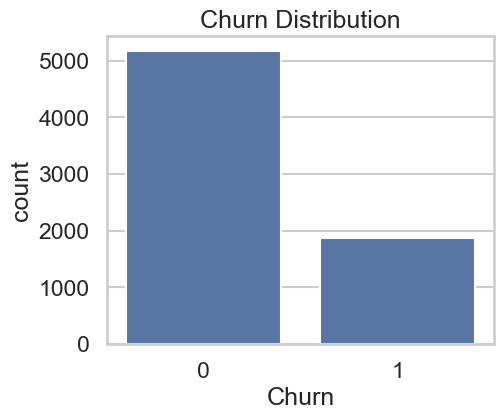

In [18]:
# Exploratory Data Analysis (EDA)

sns.set(style="whitegrid", context="talk")

# Churn distribution
plt.figure(figsize=(5, 4))
sns.countplot(x='Churn', data=data)
plt.title('Churn Distribution')
plt.show()

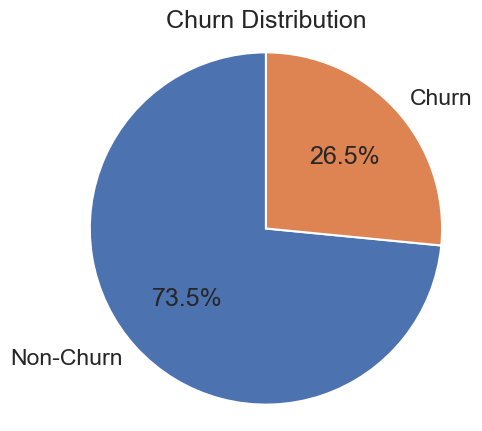

In [19]:
sns.set(style="whitegrid", context="talk")

# Churn distribution (Pie Chart)
churn_counts = data['Churn'].value_counts()

plt.figure(figsize=(5, 5))
plt.pie(
    churn_counts,
    labels=['Non-Churn', 'Churn'],
    autopct='%1.1f%%',
    startangle=90
)
plt.title('Churn Distribution')
plt.axis('equal')  # Ensures pie is circular
plt.show()

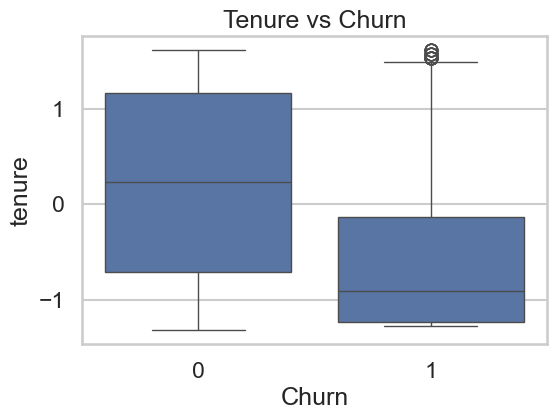

In [79]:
# Tenure vs Churn
plt.figure(figsize=(6, 4))
sns.boxplot(x='Churn', y='tenure', data=data)
plt.title('Tenure vs Churn')
plt.show()

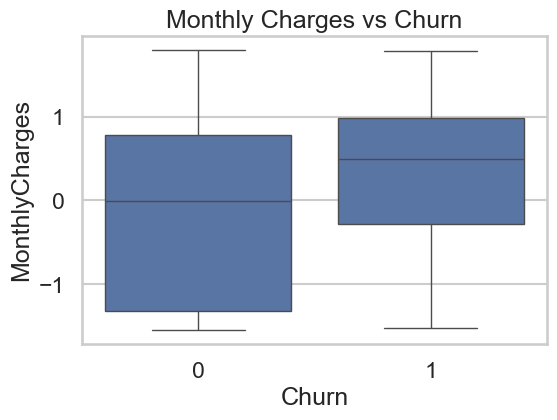

In [20]:
# MonthlyCharges vs Churn
plt.figure(figsize=(6, 4))
sns.boxplot(x='Churn', y='MonthlyCharges', data=data)
plt.title('Monthly Charges vs Churn')
plt.show()

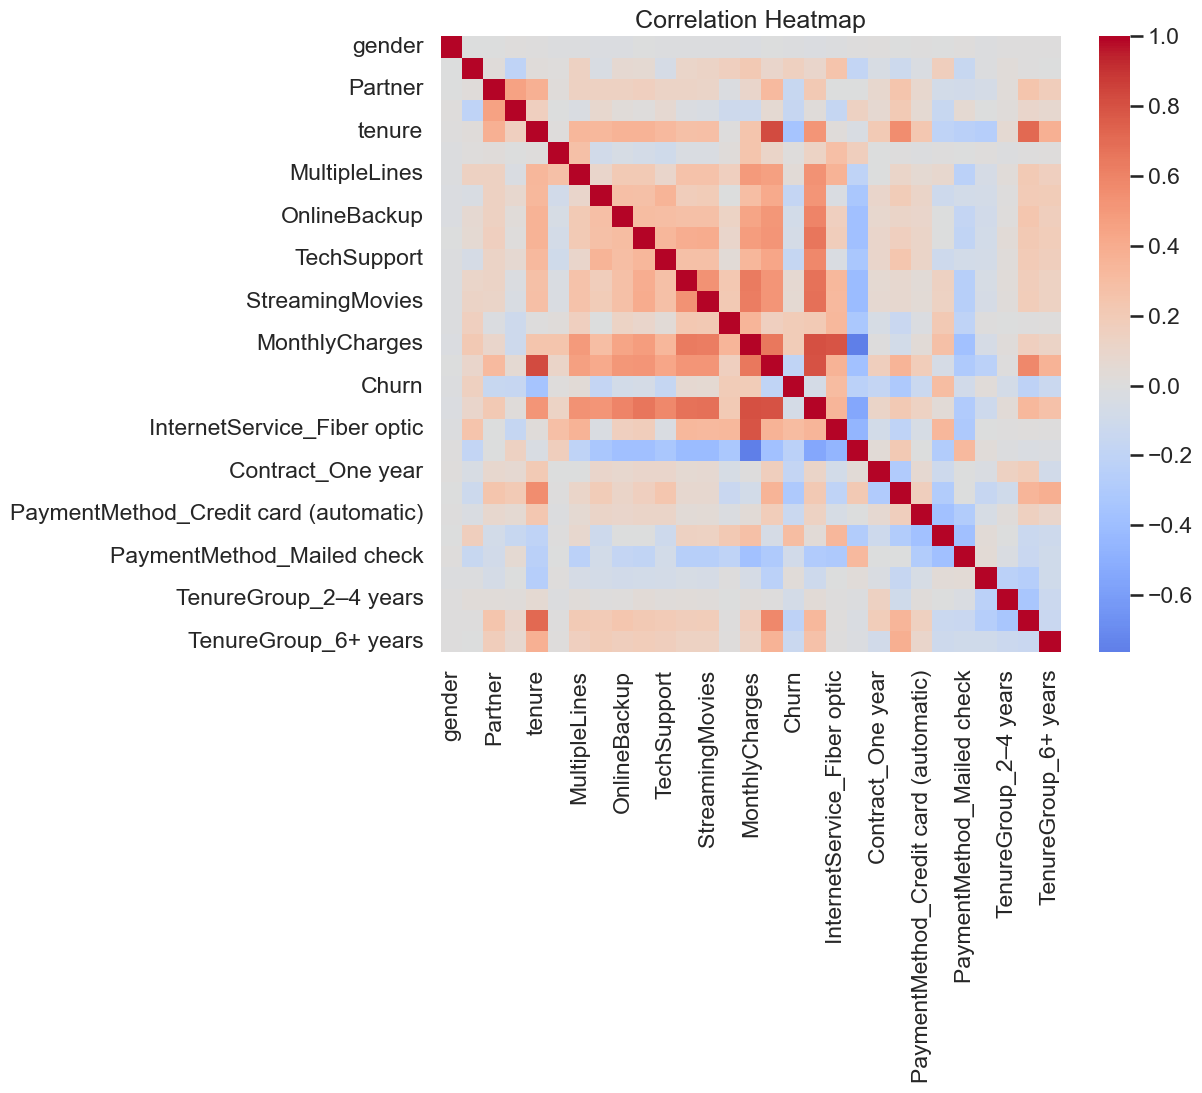

In [21]:
# Correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(data.corr(), cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

In [22]:
# Class imbalance check
print("\nChurn value counts (0 = No, 1 = Yes):")
print(data['Churn'].value_counts())
print("\nChurn rate (%):")
print(data['Churn'].value_counts(normalize=True) * 100)


Churn value counts (0 = No, 1 = Yes):
Churn
0    5174
1    1869
Name: count, dtype: int64

Churn rate (%):
Churn
0    73.463013
1    26.536987
Name: proportion, dtype: float64


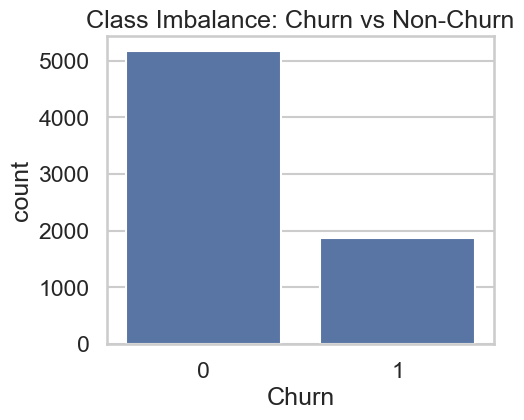

In [23]:
plt.figure(figsize=(5, 4))
sns.countplot(x='Churn', data=data)
plt.title('Class Imbalance: Churn vs Non-Churn')
plt.show()

In [24]:
# Train/Test Split & Modeling

# Features and target
X = data.drop('Churn', axis=1)
y = data['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ---------------- Baseline Logistic Regression ----------------
baseline_model = LogisticRegression(max_iter=1000)
baseline_model.fit(X_train, y_train)

y_pred_baseline = baseline_model.predict(X_test)

In [25]:
print("\nBaseline Logistic Regression Results:")
print("Accuracy:", accuracy_score(y_test, y_pred_baseline))


Baseline Logistic Regression Results:
Accuracy: 0.7991483321504613


In [26]:
print(confusion_matrix(y_test, y_pred_baseline))
print(classification_report(y_test, y_pred_baseline))

[[933 102]
 [181 193]]
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.65      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



In [33]:
from sklearn.metrics import roc_auc_score, RocCurveDisplay
import matplotlib.pyplot as plt

# Predict probabilities for the positive class (Churn = 1)
y_prob_baseline = baseline_model.predict_proba(X_test)[:, 1]

# Calculate ROC-AUC
roc_auc_baseline = roc_auc_score(y_test, y_prob_baseline)

print("ROC-AUC (Baseline Logistic Regression):", roc_auc_baseline)

ROC-AUC (Baseline Logistic Regression): 0.8429202511043943


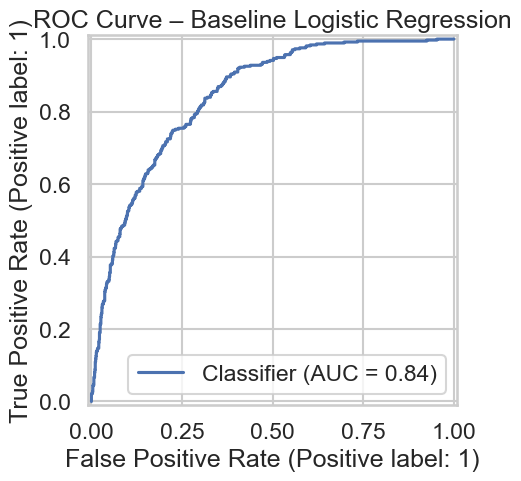

In [34]:
# Plot ROC Curve
RocCurveDisplay.from_predictions(y_test, y_prob_baseline)
plt.title("ROC Curve – Baseline Logistic Regression")
plt.show()

In [27]:
# Logistic Regression with class_weight='balanced' 
model = LogisticRegression(class_weight='balanced', max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("\nBalanced Logistic Regression Results:")
print("Accuracy:", accuracy_score(y_test, y_pred))


Balanced Logistic Regression Results:
Accuracy: 0.7324343506032647


In [28]:
print(confusion_matrix(y_test, y_pred))

[[735 300]
 [ 77 297]]


In [29]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.71      0.80      1035
           1       0.50      0.79      0.61       374

    accuracy                           0.73      1409
   macro avg       0.70      0.75      0.70      1409
weighted avg       0.80      0.73      0.75      1409



In [30]:
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

ROC-AUC: 0.8425714950011625


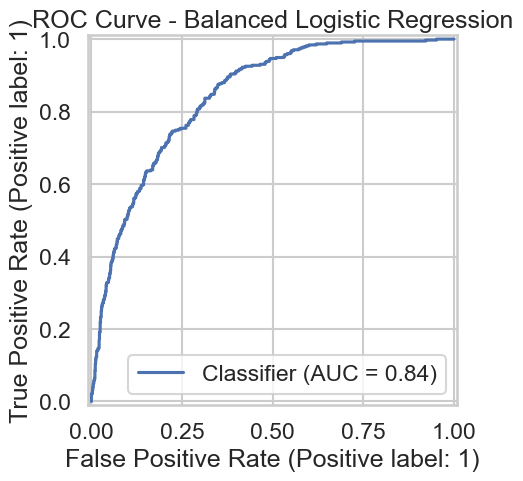

In [31]:
RocCurveDisplay.from_predictions(y_test, y_prob)
plt.title("ROC Curve - Balanced Logistic Regression")
plt.show()

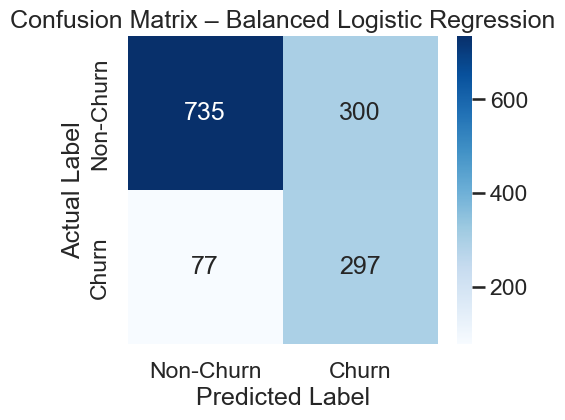

In [32]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Non-Churn', 'Churn'],
    yticklabels=['Non-Churn', 'Churn']
)
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix – Balanced Logistic Regression')
plt.show()

In [ ]:
# Random Forest for comparison

In [92]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced'
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("\nRandom Forest Results:")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))


Random Forest Results:
Accuracy: 0.7877927608232789


In [93]:
print(confusion_matrix(y_test, y_pred_rf))

[[930 105]
 [194 180]]


In [94]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1035
           1       0.63      0.48      0.55       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.70      1409
weighted avg       0.78      0.79      0.78      1409



In [95]:
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

ROC-AUC: 0.8240861298406055


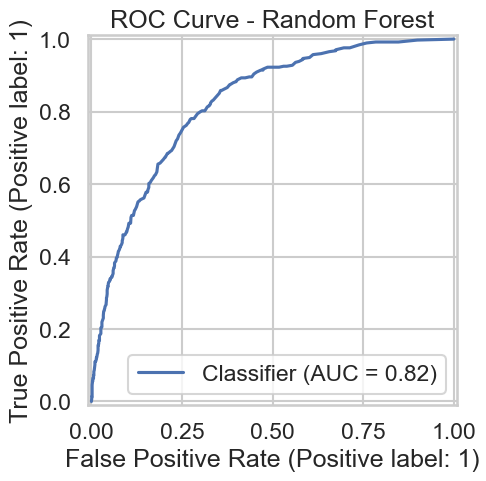

In [96]:
RocCurveDisplay.from_predictions(y_test, y_prob_rf)
plt.title("ROC Curve - Random Forest")
plt.show()